# Object detection on old maps


Goal is to detect buildings, both inhabited and un-inhabited from old maps and produce a GIS-layers of existing buildings for separate time-periods.

Further goal is then to analyze how the buildings have survived through the years.


The project was originally created in TensorFlow and Keras in 2023, now ported to pytorch-platform.

## Create the dataset

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

# Transformations
from torchvision.tv_tensors import BoundingBoxes
import torchvision.transforms.v2 as T

Create the Dataset-class, simple transformation

In [2]:
class ObjectDetectionDataset(Dataset):
    def __init__(self, csv_file, transform=None, image_subset = None):
        self.base_path = "data/images_train/" #
        self.annotations = pd.read_csv(csv_file)
        self.transform = transform

        # Group annotations by image as there are 0-n boxes per image
        self.image_groups = self.annotations.groupby("filename")

        # Unique image paths
        # NOTE: use only pre-defined-subset of the image-paths; this enables the use of train-eval split
        all_image_paths = list(self.image_groups.groups.keys())
        if image_subset is not None:
            self.image_paths = image_subset
        else:
            self.image_paths = all_image_paths

    def __len__(self): # Returns the length of the IMAGES in dataset, not boxes
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path =  self.image_paths[idx]

        # Note: take all the rows per each image, so there is no leakage between test and train.
        rows = self.image_groups.get_group(image_path) # Get all bboxes for image

        # Load image
        image = Image.open(self.base_path + image_path).convert("RGB")

        # Create lists to store the boxes and their labels
        boxes = []
        labels = []

        for _, row in rows.iterrows():
            boxes.append([
                row["xmin"],
                row["ymin"],
                row["xmax"],
                row["ymax"]
            ])
            labels.append(row["class_num"])

        # Operate based on if boxes on image:
        if len(boxes)==0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0, ), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        # Create target:
        target = {"boxes": boxes, "labels": labels}

        # Convert to BoundingBox format to use the box-aware transforms.v2 -library
        target["boxes"] = BoundingBoxes(target["boxes"],
                                        format = "XYXY",
                                        canvas_size=image.size[::1]
                                        )

        if self.transform:
            image, target = self.transform(image, target)

        return image, target

In [3]:

# OLD-transforms
# Simple transformation, i.e. converting to tensor. 
# transform = transforms.Compose([
#     transforms.ToTensor(),  # Converts to [0,1] and CHW
#     # TODO: Placeholder for image augmentation; Note that only non-position-changing (brightness, colors etc) can be used easily
# ])

In [4]:
# Trasforms for training; NOTE: ToImage + ToDtype replaces ToTensor in this new version
train_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    T.RandomAutocontrast(p=0.5)
])

# validation transforms; this only converts images to tensor, no augmentations
val_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])

Create the datasets

In [5]:
# Read first the full dataset; this will be split to eval and train later
full_dataset = ObjectDetectionDataset(
    csv_file="data/train_256px_annotations_extended_cleaned_2026.csv",
    transform=train_transforms
)

In [6]:
# Create the train-eval split
import random

# SEt seed for reprod.
random.seed(123)

# Get all images, suffle and take split.
all_images = full_dataset.image_paths
random.shuffle(all_images)
split_idx = int(0.8 * len(all_images))

train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

In [106]:
split_idx

1038

In [7]:
train_dataset = ObjectDetectionDataset(
    csv_file="data/train_256px_annotations_extended_cleaned_2026.csv",
    transform=train_transforms,
    image_subset = train_images
)

val_dataset = ObjectDetectionDataset(
    csv_file="data/train_256px_annotations_extended_cleaned_2026.csv",
    transform = val_transforms,
    image_subset = val_images
)

Create the dataloaders for both eval and train

In [8]:
# Custom collate function; it is needed for varying lenght data, to transform the list into batch (tuple) of standard size
# Here there might be different number of boxes per image, i.e. need to package into same size with collate_fn
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

### Test the dataloader


- Test shape of the outputs
- Test augmentations

In [9]:
# Shape of the outputs
temp_images, temp_targets = next(iter(train_dataloader))

# Print some example data
print(temp_images[0].shape) # RGB image; 3 x 256 x 256
print(temp_targets[0]['boxes']) # boxes; coords and some metadata
print(temp_targets[0]['labels']) # which classes boxes are

torch.Size([3, 256, 256])
BoundingBoxes([[100., 171., 117., 186.],
               [ 61.,  31.,  76.,  46.],
               [ 57.,  11.,  70.,  27.]], format=BoundingBoxFormat.XYXY, canvas_size=(256, 256), clamping_mode=soft)
tensor([1, 1, 1])


In [85]:
# 1.1234 == 1
1.000 == 1

True

In [87]:
# Helper funcs to plot augmented results

import matplotlib.pyplot as plt
import matplotlib.patches as patches


def draw_boxes(ax, boxes, labels=None, labels_digits = 0, color="lime"):
    """
    ax     : matplotlib axis
    boxes  : Tensor[N, 4] in XYXY format
    labels : optional Tensor[N]
    """
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1),
            w,
            h,
            linewidth=2,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

        if labels is not None:
            # decide the number of digits shown; for labels, this is 0, for scores, it is 2 digits
            if labels_digits == 0:
                labels_text = str(int(labels[i]))
            else:
                labels_text = f"{labels[i]:.{labels_digits}f}"
            ax.text(
                x1,
                y1 - 3,
                labels_text,
                color=color,
                fontsize=9,
                bbox=dict(facecolor="black", alpha=0.5, pad=1)
            )


def visualize_batch(dataloader, max_images=4):
    images, targets = next(iter(dataloader))

    batch_size = min(len(images), max_images)
    fig, axes = plt.subplots(1, batch_size, figsize=(5 * batch_size, 5))

    if batch_size == 1:
        axes = [axes]

    for i in range(batch_size):
        image = images[i]
        target = targets[i]

        # CHW → HWC
        img_np = image.permute(1, 2, 0).cpu().numpy()

        axes[i].imshow(img_np)
        axes[i].axis("off")

        boxes = target["boxes"]
        labels = target["labels"]

        # BoundingBoxes → Tensor (important)
        if hasattr(boxes, "to_tensor"):
            boxes = boxes.to_tensor()

        if len(boxes) > 0:
            draw_boxes(axes[i], boxes, labels)

    plt.tight_layout()
    plt.show()


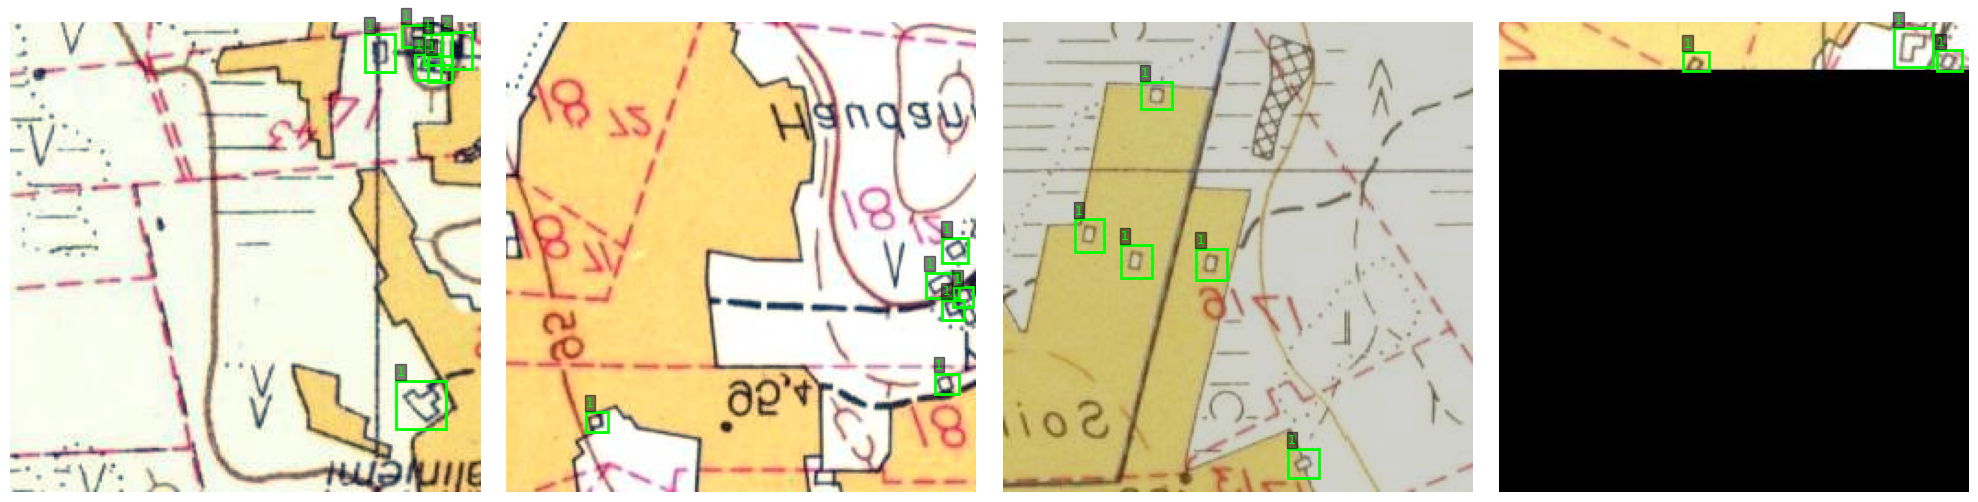

In [11]:
# Augmentations and suffling for training-data:
visualize_batch(train_dataloader, max_images=4)

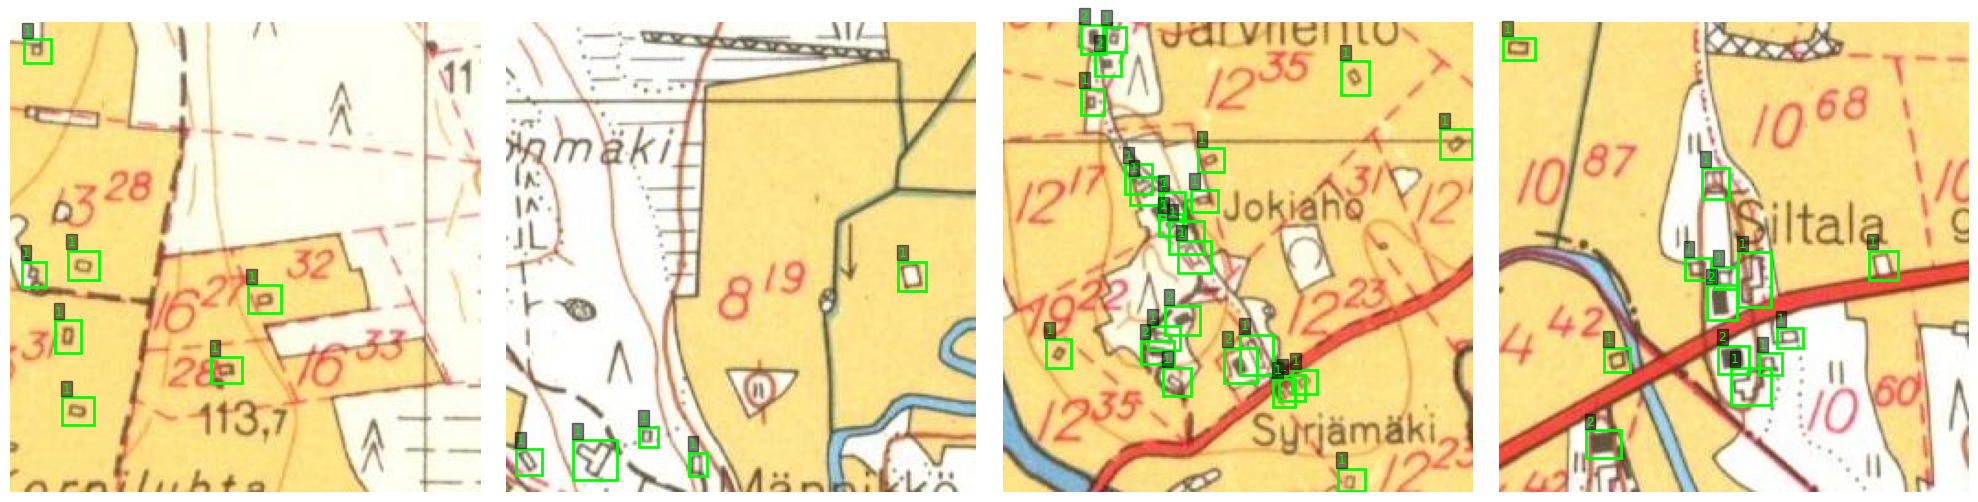

In [12]:
# NOTE: Should NOT have any augmentation or shuffling for validation.
visualize_batch(val_dataloader, max_images=4) 

## Model

In [13]:
# import torchvision.models.detection.fasterrcnn_resnet50_fpn

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead

In [14]:

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    # pretrained=True, # Deprecated param
    weights='FasterRCNN_ResNet50_FPN_Weights.DEFAULT',
    min_size=256,
    max_size=256
)


### Inspect model params and internals

In [15]:
# Inspect the internal stucture of the model and its params at high level
def print_module_tree(module, prefix=""):
    for name, child in module.named_children():
        print(prefix + name, "→", type(child))
        print_module_tree(child, prefix + "  ")

print_module_tree(model)

transform → <class 'torchvision.models.detection.transform.GeneralizedRCNNTransform'>
backbone → <class 'torchvision.models.detection.backbone_utils.BackboneWithFPN'>
  body → <class 'torchvision.models._utils.IntermediateLayerGetter'>
    conv1 → <class 'torch.nn.modules.conv.Conv2d'>
    bn1 → <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
    relu → <class 'torch.nn.modules.activation.ReLU'>
    maxpool → <class 'torch.nn.modules.pooling.MaxPool2d'>
    layer1 → <class 'torch.nn.modules.container.Sequential'>
      0 → <class 'torchvision.models.resnet.Bottleneck'>
        conv1 → <class 'torch.nn.modules.conv.Conv2d'>
        bn1 → <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
        conv2 → <class 'torch.nn.modules.conv.Conv2d'>
        bn2 → <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
        conv3 → <class 'torch.nn.modules.conv.Conv2d'>
        bn3 → <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
        relu → <class 'torch.nn.modules.activation.ReLU'>
        dow

In [16]:
# Detailed view of model params and WHERE they are.

# Looping over all the params of the model: 
# NOTE: Tested and Level 4 is irrelavant; they are methods for converting the inputs from float, nominators etc.
# Use only the level 3
model_param_list = []

for attr_l1 in dir(model):
    for attr_l2 in dir(getattr(model, attr_l1)):
        attr_l3 = dir(getattr(getattr(model, attr_l1), attr_l2))
        model_param_list.append(pd.DataFrame({'L1': attr_l1, 'L2': attr_l2, 'L3': attr_l3}))


# for attr_l1 in dir(model):
#     for attr_l2 in dir(getattr(model, attr_l1)):
#         for attr_l3 in dir(getattr(getattr(model, attr_l1), attr_l2)):
#             print(attr_l1, attr_l2, attr_l3)
#             try:
#                 attr_l4 = dir(getattr(getattr(getattr(model, attr_l1), attr_l2), attr_l3))
#             except:
#                 attr_l4 = ["no_attributes"]
#             model_param_list.append(pd.DataFrame({'L1': attr_l1, 'L2': attr_l2, 'L3': attr_l3, 'L4': attr_l4}))

# Combine and filter out internal params starting with underscore
model_param_list_df = pd.concat(model_param_list, ignore_index = True)
model_param_list_df2 = model_param_list_df[(~model_param_list_df.L1.str.startswith("_"))&(~model_param_list_df.L2.str.startswith("_"))&(~model_param_list_df.L3.str.startswith("_"))].copy()

# Create one additional column for easy string-searching
model_param_list_df2['L123'] = model_param_list_df2['L1'] + '.' + model_param_list_df2['L2'] + '.' + model_param_list_df2['L3']

In [17]:
# NOTE:
# Many similar params exists at level L3 between L1-modules roi_heads and rpn. rpn is the first step in the journey,
# and therefore needs to be tuned first
# RPN = Region Proposal Network: "Where any of the objects are" (Coarse regions of potential candidates for deeper inspection)
# ROI_Heads: Region Of Interest: "Where exactly and what are the objects (classification + finetuning box coords)"

model_param_list_df2[model_param_list_df2.L123.str.contains("batch_size_per_image")]



,L1,L2,L3,L123
141431,roi_heads,fg_bg_sampler,batch_size_per_image,roi_heads.fg_bg_sampler.batch_size_per_image
146446,rpn,fg_bg_sampler,batch_size_per_image,rpn.fg_bg_sampler.batch_size_per_image


In [18]:
dir(model.rpn.fg_bg_sampler)

['__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'batch_size_per_image',
 'positive_fraction']

In [19]:
# TODO: Search all the relevant runable params and get their names and locations + default-values

### Adjust model parameters to the current case


Customize the number of classes and create a new box-predictor-head with updated number of classes

In [20]:
# model.roi_heads.box_predictor # Predict the classes and bbox-coordinates, so output for cls is 3 and bbox 3 * 4 coords (12)
num_classes = 3  # background + 2 object classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

Parameter tuning - need to customize for the small objects, as they are only covering 1% of the image-area.

In [41]:
# Examine the number of Pyramid-levels in FPN by printing the model backbone:
# This is needed for the anchors as each pyramid-level needs to have the sizes & aspect_ratios specified
# print(model.backbone)
# --> 4 conv2d layers (inner_block) (5th is just a smoothing operation), 
# and 6TH LAYER is max-pooling, which is the 5th real layer


# Adjust the generator to much smaller anchors; default sizes are 32, 64, 128, 256, 512
anchor_generator = AnchorGenerator(
    sizes=((8,),
           (12,),
           (16,),
           (24,),
           (32,),),  # MUCH smaller than defaults; note that these are taken from EDA
    aspect_ratios=((0.5, 1.0, 1.5),                 (0.5, 1.0, 1.5),
                   (0.5, 1.0, 1.5),
                   (0.5, 1.0, 1.5),
                   (0.5, 1.0, 1.5),)
)

model.rpn.anchor_generator = anchor_generator

In [40]:
print(f"aspect_ratios: new: {anchor_generator.aspect_ratios} --- default: {model.rpn.anchor_generator.aspect_ratios}")
# print(f"ipu: new: {anchor_generator.ipu} --- default: {model.rpn.anchor_generator.ipu}")
# print(f"mtia: new: {anchor_generator.mtia} --- default: {model.rpn.anchor_generator.mtia}")
print(f"num_anchors_per_location: new: {anchor_generator.num_anchors_per_location()} --- default: {model.rpn.anchor_generator.num_anchors_per_location()}")
# print(f"parameters: new: {anchor_generator.parameters} --- default: {model.rpn.anchor_generator.parameters}")
# print(f"named_parameters: new: {anchor_generator.named_parameters} --- default: {model.rpn.anchor_generator.named_parameters}")
print(f"sizes: new: {anchor_generator.sizes} --- default: {model.rpn.anchor_generator.sizes}")


aspect_ratios: new: ((0.5, 1.0, 1.5), (0.5, 1.0, 1.5), (0.5, 1.0, 1.5), (0.5, 1.0, 1.5), (0.5, 1.0, 1.5)) --- default: ((0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0))
num_anchors_per_location: new: [3, 3, 3, 3, 3] --- default: [3, 3, 3, 3, 3]
sizes: new: ((8,), (12,), (16,), (24,), (32,)) --- default: ((32,), (64,), (128,), (256,), (512,))


In [42]:
# NOTE:If the above is different from default (3 anchors per location) change the RPN-head, as it expects the basic 1 sizes x 3 aspect-ratios (3 anchors) per each pyramic level
print(anchor_generator.num_anchors_per_location())

# model.rpn.head = RPNHead(
#     in_channels=256,  # FPN output channels
#     num_anchors=anchor_generator.num_anchors_per_location()
# )

[3, 3, 3, 3, 3]


In [43]:
# Treshold for the detection; these are IoU-ratios (Intersection over Union, i.e. how 
# much of the areas overlap between model-proposed vs. ground-truth training-labels)

# High-limit; only higher than these are passed on as correct anchors for training.
# Settng here very high limit, as the objects are completely "wrong" if the overlap is too small and part is cut out.
# Chat-GPT suggestested this to be LOWER to allow for multiple positive matches....
model.rpn.proposal_matcher.high_threshold = 0.9 # defaults to 0.7; higher than this are consider good matches

# Low limit; lower than this are background
model.rpn.proposal_matcher.low_threshold # defaults to 0.3; LOWER than this are consider background, i.e. 

0.3

In [44]:
# How many samples per image? If objects are relatively rare (i.e. most is background), this should be incresed
# dir(model.rpn.fg_bg_sampler) # Contains variables 'batch_size_per_image' and 'positive_fraction'

model.rpn.fg_bg_sampler.batch_size_per_image # defaults to 256 samples
model.rpn.fg_bg_sampler.positive_fraction # defaults to 0.5


0.5

In [ ]:
# Region-Of-Interest (ROI): Finetuning the anchored area:
# Setting to lower increases number of detections --> lift later to reduce false positives
# model.roi_heads.score_thresh # defaults to 0.05
# model.roi_heads.score_thresh = 0.3

In [ ]:
# Non-maximum-supression (nms): How much overlap is tolerated? Lower means clustered objects are outputted as single
# model.roi_heads.nms_thresh # def 0.5
# model.roi_heads.nms_thresh = 0.5

In [45]:
# How many objects to detect from image?
model.roi_heads.detections_per_img # defaults to 100
# model.roi_heads.detections_per_img = 100

100

### Move model to device

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Model ready on device:", device)

Model ready on device: cuda


In [47]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr = 0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size = 5,
    gamma = 0.1
)

## Train

In [48]:
# Meta params
plt.ion() # Interactive mode for plotting is on

num_epochs = 15

train_losses = []
val_losses = []

Epoch1/15, train: 0.2835, val: 0.2726


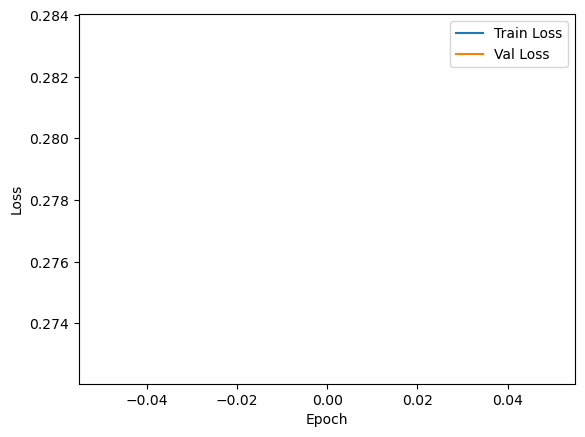

Epoch2/15, train: 0.2336, val: 0.2669


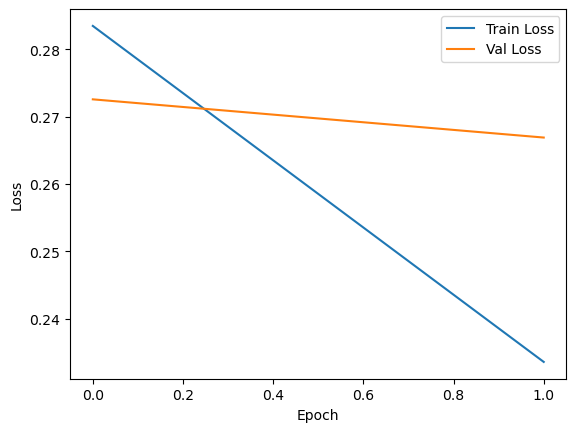

Epoch3/15, train: 0.2259, val: 0.2520


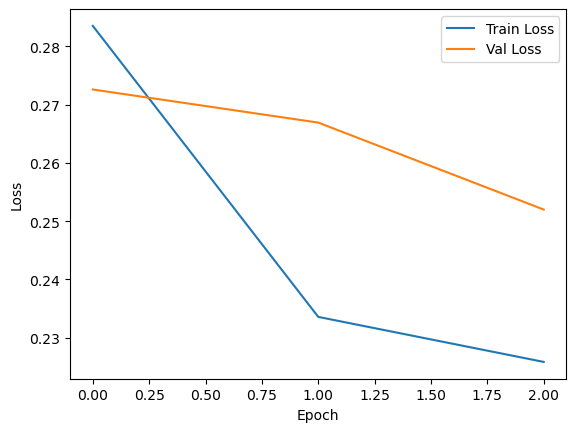

Epoch4/15, train: 0.2181, val: 0.2021


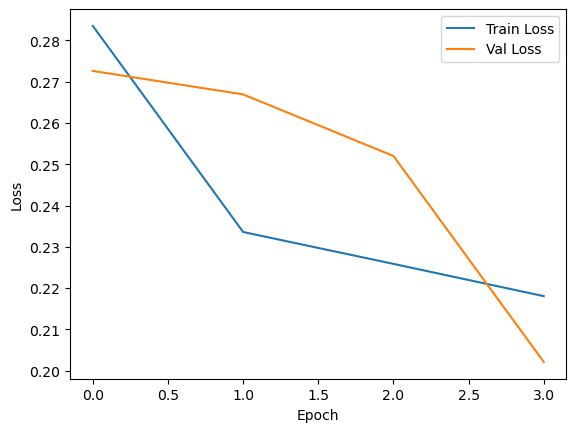

Epoch5/15, train: 0.1999, val: 0.2180


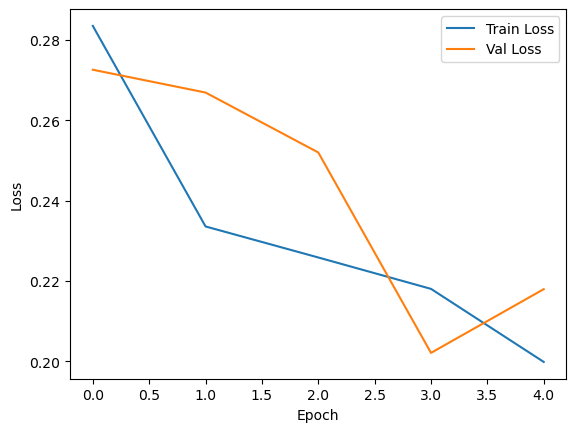

Epoch6/15, train: 0.1959, val: 0.2173


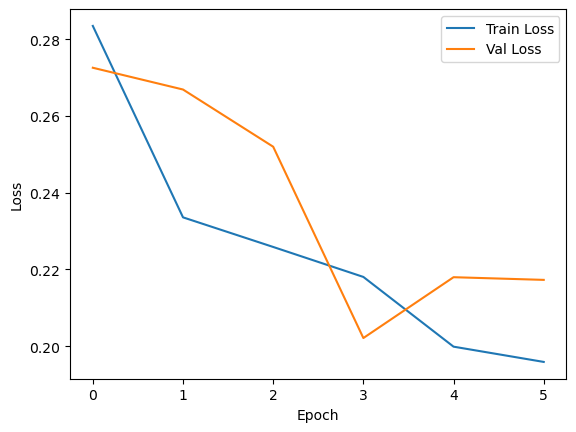

Epoch7/15, train: 0.2005, val: 0.2200


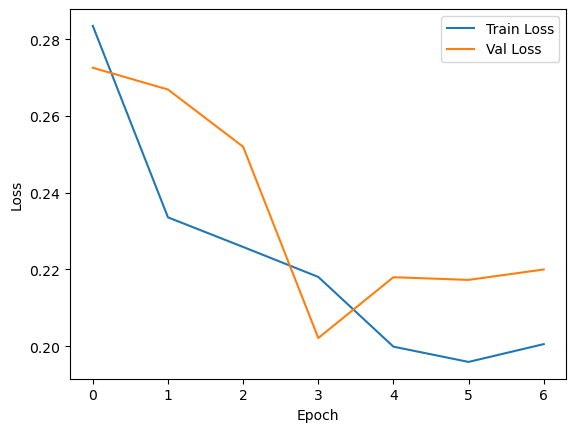

Epoch8/15, train: 0.1999, val: 0.2217


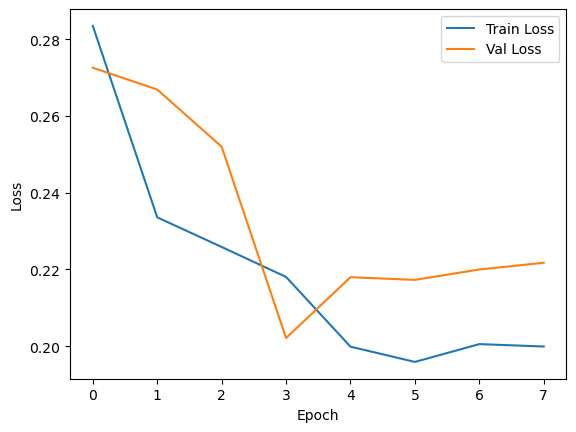

Epoch9/15, train: 0.2022, val: 0.2203


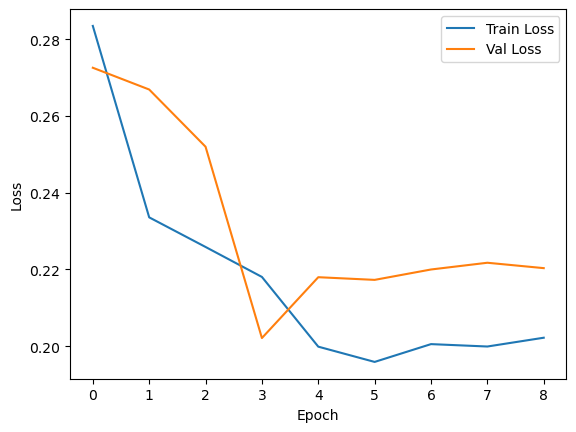

Epoch10/15, train: 0.1993, val: 0.2205


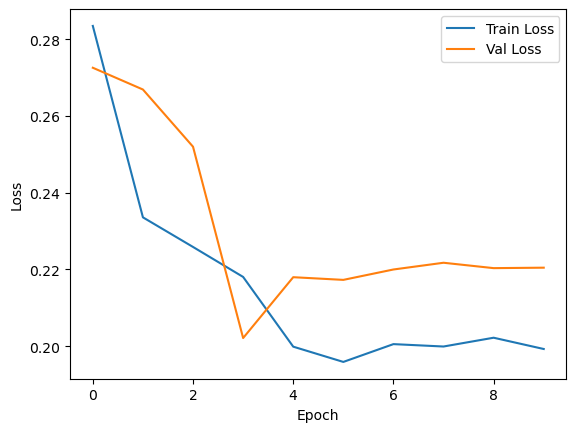

Epoch11/15, train: 0.1966, val: 0.2239


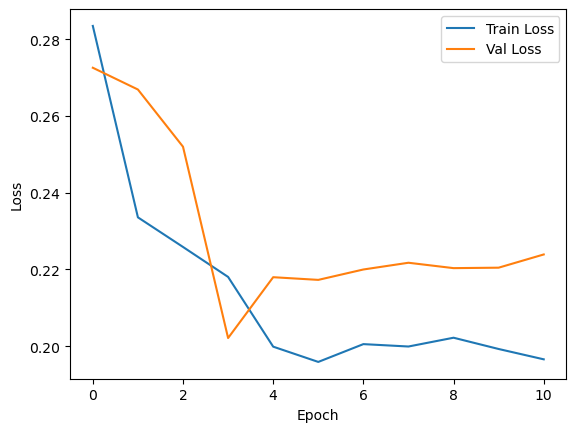

Epoch12/15, train: 0.1983, val: 0.2204


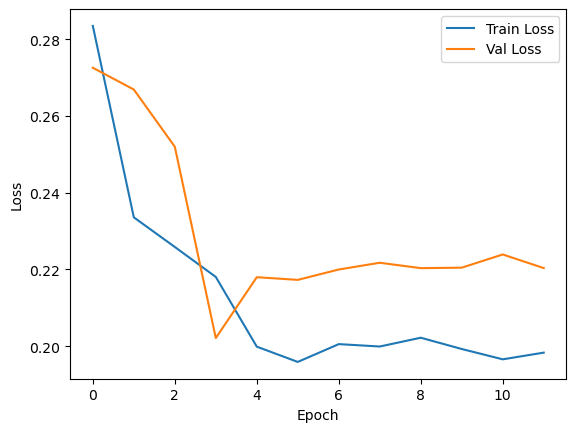

Epoch13/15, train: 0.1991, val: 0.2211


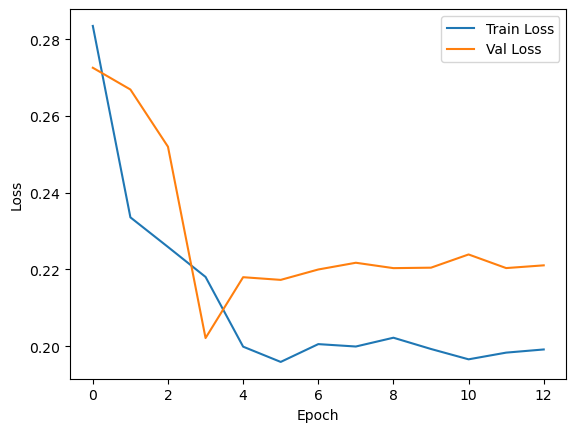

Epoch14/15, train: 0.1982, val: 0.2207


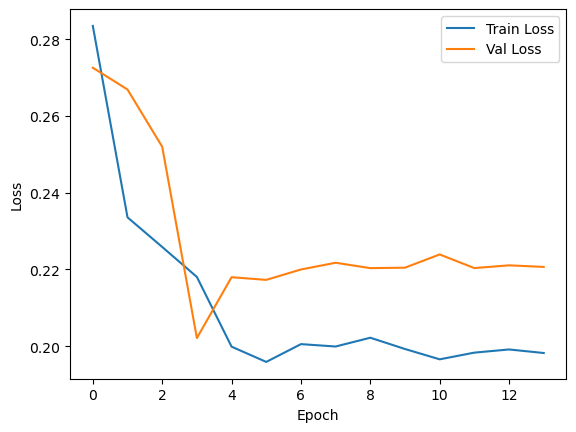

Epoch15/15, train: 0.1972, val: 0.2207


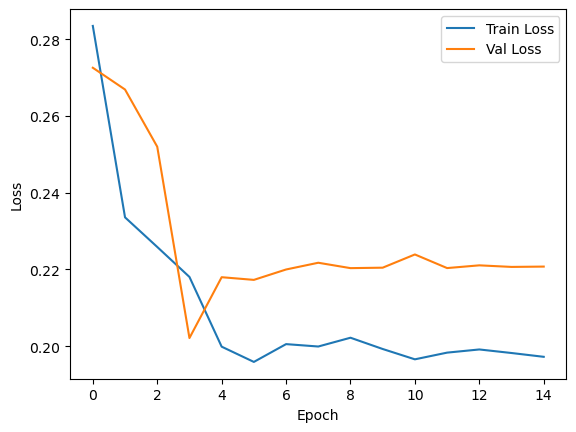

In [49]:
for epoch in range(num_epochs):

    # ----------------  Training ----------------
    model.train()
    epoch_train_loss = 0

    # Get all images and targets in dataloader
    for images, targets in train_dataloader:

        # Send images to device
        images = [img.to(device) for img in images]

        # Send targets to device; 
        # note, only sends the 'key: value' -dictionaries
        targets = [
            {k: v.to(device) for k, v in t.items()} for t in targets
        ]

        # Forward pass:
        # Get the loss from model and sum
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass;
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # Get the total loss for training epoch
        epoch_train_loss += losses.item()

    # Get the average loss per image
    epoch_train_loss /= len(train_dataloader)
    train_losses.append(epoch_train_loss)

    # After epoch is ready, advance the learning-rate-scheduler by one step
    lr_scheduler.step()

    # ------------------ Validation --------------------
    model.train() # NOTE: Keep in train-model to get the loss (only available in train)
    epoch_val_loss = 0

    with torch.no_grad():
        for images, targets in val_dataloader:
            images = [img.to(device) for img in images]
            targets = [
                {k: v.to(device) for k, v in t.items()} for t in targets
            ]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            epoch_val_loss += losses.item()

    epoch_val_loss /= len(val_dataloader)
    val_losses.append(epoch_val_loss)


    # Print the stats for each epoch
    print(f"Epoch{epoch+1}/{num_epochs}, train: {epoch_train_loss:.4f}, val: {epoch_val_loss:.4f}")

    # Plot
    plt.clf()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.pause(0.01)


In [ ]:
# After training, do evaluation-predicitons
# Set the model to evaluation mode; omits the dropout etc.
model.eval()

# Output is list of dicts: each list-element is for one image in validation data. dict_keys(['boxes', 'labels', 'scores'])
with torch.no_grad():
    for images, targets in val_dataloader:
        images = [img.to(device) for img in images]
        test_outputs = model(images)
        # TODO: calculate success metrics lie mAP, IoU, precision and recall

In [70]:
test_outputs[0]

{'boxes': tensor([[138.8652, 176.6535, 153.3182, 190.5579],
         [182.7079, 161.2361, 197.6113, 176.5321],
         [210.9007, 152.8689, 226.3986, 168.3707],
         [208.9720, 150.0287, 231.2187, 171.8363],
         [142.4034,  25.0119, 154.5948,  39.7321],
         [166.7608, 168.8931, 183.4827, 184.7857],
         [111.6047,  40.1050, 127.4188,  55.6144],
         [182.4248,  94.7833, 198.5801, 111.0574],
         [114.0222,  53.1525, 134.5930,  76.0498],
         [114.6279,  56.0524, 130.0218,  71.2077],
         [104.7020,  18.0544, 120.2042,  33.4614],
         [158.2888, 174.0491, 174.0707, 190.2055],
         [157.0150, 176.8371, 172.1665, 189.5327],
         [113.1808,  48.5110, 128.9968,  64.4000],
         [118.4704,  69.9011, 134.6246,  88.6999],
         [ 71.7953, 232.9215,  91.0079, 247.9179],
         [186.1635, 163.8750, 195.5658, 172.9701],
         [111.6757,  39.9308, 127.5344,  56.5101],
         [175.6001, 166.3912, 191.3127, 182.7784],
         [188.1762, 16

In [88]:
# Function to plot the single image from validation data set
# PLUS the real boxes
# PLUS the predicted boxes, along with the confidences

def plot_predictions(image_idx, val_dataset, predictions, score_filter_treshold = 0.5):
    c_image, c_targets = val_dataset[image_idx]
    c_target_boxes, c_target_labels = c_targets['boxes'], c_targets['labels']

    c_preds = predictions[image_idx]
    c_preds_boxes, c_preds_labels, c_preds_scores = c_preds['boxes'], c_preds['labels'], c_preds['scores']

    fig, axes = plt.subplots(1, 1, figsize = (10, 10))

    # Plot image
    # Channel conversion - needed?
    img_np = c_image.permute(1, 2, 0).cpu().numpy()
    axes.imshow(img_np)

    # Add ground-truth-boxes (convert to tensor)
    if hasattr(c_target_boxes, "to_tensor"):
        c_target_boxes = c_target_boxes.to_tensor()

    if len(c_target_boxes) > 0:
        draw_boxes(axes, c_target_boxes, c_target_labels, color = 'red')

    # Add predictions + confidences
    # Filter by the score to only show the limited number
    c_preds_boxes = c_preds_boxes[c_preds_scores > score_filter_treshold]
    c_preds_labels = c_preds_labels[c_preds_scores > score_filter_treshold]
    c_preds_scores = c_preds_scores[c_preds_scores > score_filter_treshold]

    if len(c_preds_boxes) > 0:
        draw_boxes(ax = axes, boxes = c_preds_boxes, labels = c_preds_scores, labels_digits = 2, color = 'purple')
    
    plt.show()
    

In [105]:
val_dataset.index()

AttributeError: 'ObjectDetectionDataset' object has no attribute 'index'

In [76]:
koe_boxes, koe_labels, koe_scores = test_outputs[1]['boxes'], test_outputs[1]['labels'], test_outputs[1]['scores']

In [82]:
koe_boxes_filtered = koe_boxes[koe_scores > 0.5]
koe_boxes_filtered

tensor([[ 89.1705, 141.9623, 104.4680, 154.0667],
        [202.1276,  93.5435, 215.5722, 106.0786],
        [205.5236, 104.7643, 220.8379, 120.1031],
        [152.2798,  73.1075, 168.3433,  87.6548]], device='cuda:0')

In [ ]:
# TODO:
# Get all the eval-images to plot - now only plot the idx 0-3.....
# Test training from scratch without the pre-trained weights (or using pre-trained, but freezing the low-level layers only?)
# Plot in SINGLE image during the training ( use the tensorboard properly to log the graphics)

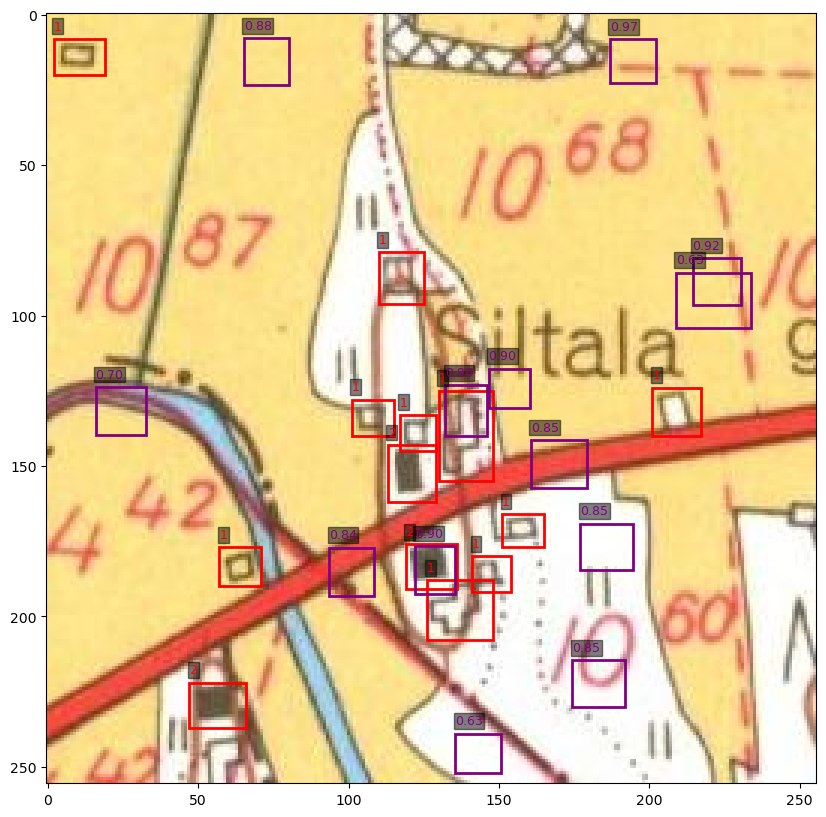

In [110]:
plot_predictions(image_idx = 3, val_dataset = val_dataset, predictions = test_outputs, score_filter_treshold=0.6)

In [73]:
# val_dataset[0][0]
# val_dataset[0][1].keys()
dir(val_dataset[0][1]['boxes'])

val_dataset[0][1]['boxes'].to_tensor()

AttributeError: 'BoundingBoxes' object has no attribute 'to_tensor'

In [ ]:
def visualize_batch(dataloader, max_images=4):
    images, targets = next(iter(dataloader))

    batch_size = min(len(images), max_images)
    fig, axes = plt.subplots(1, batch_size, figsize=(5 * batch_size, 5))

    if batch_size == 1:
        axes = [axes]

    for i in range(batch_size):
        image = images[i]
        target = targets[i]

        # CHW → HWC
        img_np = image.permute(1, 2, 0).cpu().numpy()

        axes[i].imshow(img_np)
        axes[i].axis("off")

        boxes = target["boxes"]
        labels = target["labels"]

        # BoundingBoxes → Tensor (important)
        if hasattr(boxes, "to_tensor"):
            boxes = boxes.to_tensor()

        if len(boxes) > 0:
            draw_boxes(axes[i], boxes, labels)

    plt.tight_layout()
    plt.show()

In [60]:
test_outputs[0]


{'boxes': tensor([[138.8652, 176.6535, 153.3182, 190.5579],
         [182.7079, 161.2361, 197.6113, 176.5321],
         [210.9007, 152.8689, 226.3986, 168.3707],
         [208.9720, 150.0287, 231.2187, 171.8363],
         [142.4034,  25.0119, 154.5948,  39.7321],
         [166.7608, 168.8931, 183.4827, 184.7857],
         [111.6047,  40.1050, 127.4188,  55.6144],
         [182.4248,  94.7833, 198.5801, 111.0574],
         [114.0222,  53.1525, 134.5930,  76.0498],
         [114.6279,  56.0524, 130.0218,  71.2077],
         [104.7020,  18.0544, 120.2042,  33.4614],
         [158.2888, 174.0491, 174.0707, 190.2055],
         [157.0150, 176.8371, 172.1665, 189.5327],
         [113.1808,  48.5110, 128.9968,  64.4000],
         [118.4704,  69.9011, 134.6246,  88.6999],
         [ 71.7953, 232.9215,  91.0079, 247.9179],
         [186.1635, 163.8750, 195.5658, 172.9701],
         [111.6757,  39.9308, 127.5344,  56.5101],
         [175.6001, 166.3912, 191.3127, 182.7784],
         [188.1762, 16